#### Load environment variables

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Tool Definition

Let's start by defining some simple tools that an email assistant will use with the `@tool` decorator:

In [2]:
from typing import Literal
from datetime import datetime
from pydantic import BaseModel
from langchain_core.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

@tool
class Done(BaseModel):
      """E-mail has been sent."""
      done: bool

## **Email Agent**

In [3]:
from langgraph.graph import MessagesState

class State(MessagesState):
    # We can add a specific key to our state for the email input
    email_input: dict
    classification_decision: Literal["ignore", "respond", "notify"]

#### Triage node

We define a python function with our triage routing logic.

For this, we use [structured outputs](https://python.langchain.com/docs/concepts/structured_outputs/) with a Pydantic model, which is particularly useful for defining structured output schemas because it offers type hints and validation. The descriptions in the pydantic model are important because they get passed as part JSON schema to the LLM to inform the output coercion.

In [4]:
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langgraph.graph import END
from langgraph.types import Command
from prompts import triage_system_prompt, triage_user_prompt, default_triage_instructions, default_background
from utils import parse_email, format_email_markdown
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.environ["GROQ_API_KEY"]

In [5]:
class RouterSchema(BaseModel):
    """Analyze the unread email and route it according to its content."""
    reasoning: str = Field(
        description="Step by Step reasoning behind the classifications"
    )
    classifications: Literal["ignore", "respond", "notify"] = Field(
        description= """
        The classifications of an email: 'ignore' for irrelevant emails, 
        'notify' for important information that doesn't need a response,
        'respond' for emails that need to reply.
        """

    )

llm = init_chat_model(
    model_provider="groq",
    model="qwen/qwen3-32b",
    temperature=0.1
)
llm_router = llm.with_structured_output(RouterSchema)

In [6]:
class RouterSchema(BaseModel):
    """Analyze the unread email and route it according to its content."""

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

# Initialize the LLM for use with router / structured output
# llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_router = llm.with_structured_output(RouterSchema) 

def triage_router(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """Analyze email content to decide if we should respond, notify, or ignore."""
    
    author, to, subject, email_thread = parse_email(state["email_input"])
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=default_triage_instructions
    )

    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )
    
    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email: \n\n{format_email_markdown(subject, author, to, email_thread)}",
                }
            ],
            "classification_decision": result.classification,
        }
        
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        goto = END
        update =  {
            "classification_decision": result.classification,
        }
        
    elif result.classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information")
        # For now, we go to END. But we will add to this later!
        goto = END
        update = {
            "classification_decision": result.classification,
        }
        
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

## ***Time to Build the Agent***

In [7]:
from prompts import agent_system_prompt, default_response_preferences, default_cal_preferences
from prompt_templates import AGENT_TOOLS_PROMPT

In [8]:
print(AGENT_TOOLS_PROMPT)


1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings where preferred_day is a datetime object
3. check_calendar_availability(day) - Check available time slots for a given day
4. Done - E-mail has been sent



In [9]:
tools = [write_email, schedule_meeting, check_calendar_availability, Done]

tools_by_name = {tool.name: tool for tool in tools}
print(tools_by_name)

{'write_email': StructuredTool(name='write_email', description='Write and send an email.', args_schema=<class 'langchain_core.utils.pydantic.write_email'>, func=<function write_email at 0x729a074dab60>), 'schedule_meeting': StructuredTool(name='schedule_meeting', description='Schedule a calendar meeting.', args_schema=<class 'langchain_core.utils.pydantic.schedule_meeting'>, func=<function schedule_meeting at 0x729a06423060>), 'check_calendar_availability': StructuredTool(name='check_calendar_availability', description='Check calendar availability for a given day.', args_schema=<class 'langchain_core.utils.pydantic.check_calendar_availability'>, func=<function check_calendar_availability at 0x729a20e40860>), 'Done': StructuredTool(name='Done', description='E-mail has been sent.', args_schema=<class 'langchain_core.utils.pydantic.Done'>, func=<class '__main__.Done'>)}


In [10]:
# Collect all tools
tools = [write_email, schedule_meeting, check_calendar_availability, Done]
tools_by_name = {tool.name: tool for tool in tools}

# Initialize the LLM, enforcing tool use
# llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_with_tools = llm.bind_tools(tools, tool_choice="any")

def llm_call(state: State):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            # Invoke the LLM
            llm_with_tools.invoke(
                # Add the system prompt
                [   
                    {"role": "system", "content": agent_system_prompt.format(
                        tools_prompt=AGENT_TOOLS_PROMPT,
                        background=default_background,
                        response_preferences=default_response_preferences,
                        cal_preferences=default_cal_preferences, 
                    )}
                ]
                # Add the current messages to the prompt
                + state["messages"]
            )
        ]
    }

## **Tool Handler Node**

In [11]:
def tool_handler(state: State):
    """Performs the tool call."""

    # List for tool messages
    result = []
    
    # Iterate through tool calls
    for tool_call in state["messages"][-1].tool_calls:
        # Get the tool
        tool = tools_by_name[tool_call["name"]]
        # Run it
        observation = tool.invoke(tool_call["args"])
        # Create a tool message
        result.append({"role": "tool", "content" : observation, "tool_call_id": tool_call["id"]})
    
    # Add it to our messages
    return {"messages": result}

## **Conditional Routing**

In [12]:
def should_continue(state: State) -> Literal["tool_handler", "__end__"]:
    """Route to tool handler, or end if Done tool called."""
    
    # Get the last message
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if it's a Done tool call
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls: 
            if tool_call["name"] == "Done":
                return END
            else:
                return "tool_handler"

## **Agent Graph**

In [13]:
from langgraph.graph import StateGraph, START, END
from utils import show_graph

# Build workflow
overall_workflow = StateGraph(State)

# Add nodes
overall_workflow.add_node("llm_call", llm_call)
overall_workflow.add_node("tool_handler", tool_handler)

# Add edges
overall_workflow.add_edge(START, "llm_call")
overall_workflow.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_handler": "tool_handler",
        END: END,
    },
)
overall_workflow.add_edge("tool_handler", "llm_call")

# Compile the agent
agent = overall_workflow.compile()

## **Combine workflow with our agent**

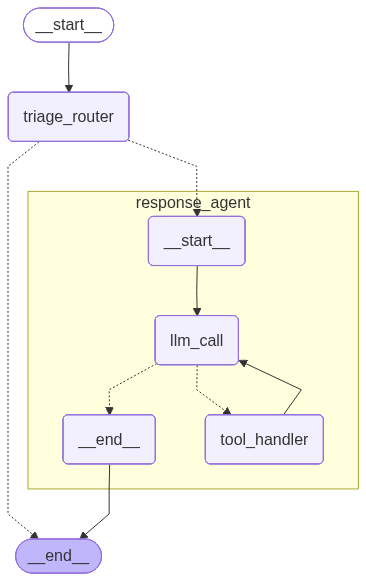

In [14]:
overall_workflow = (
    StateGraph(State)
    .add_node(triage_router)
    .add_node("response_agent", agent)
    .add_edge(START, "triage_router")
).compile()

show_graph(overall_workflow, xray=True)

In [15]:
email_input = {
    "author": "System Admin <sysadmin@company.com>",
    "to": "Development Team <dev@company.com>",
    "subject": "Scheduled maintenance - database downtime",
    "email_thread": "Hi team,\n\nThis is a reminder that we'll be performing scheduled maintenance on the production database tonight from 2AM to 4AM EST. During this time, all database services will be unavailable.\n\nPlease plan your work accordingly and ensure no critical deployments are scheduled during this window.\n\nThanks,\nSystem Admin Team"
}

# Run the agent
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

🔔 Classification: NOTIFY - This email contains important information


In [16]:
email_input = {
  "author": "Alice Smith <alice.smith@company.com>",
  "to": "John Doe <john.doe@company.com>",
  "subject": "Quick question about API documentation",
  "email_thread": "Hi John,\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\nThanks!\nAlice"
}

# Run the agent
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

📧 Classification: RESPOND - This email requires a response
================================ Human Message =================================

Respond to the email: 



**Subject**: Quick question about API documentation
**From**: Alice Smith <alice.smith@company.com>
**To**: John Doe <john.doe@company.com>

Hi John,
I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?
Specifically, I'm looking at:
- /auth/refresh
- /auth/validate
Thanks!
Alice

---

================================== Ai Message ==================================
Tool Calls:
  write_email (1213x1nm4)
 Call ID: 1213x1nm4
  Args:
    content: Hi Alice,

Thank you for bringing this to our attention. I'll check with the team to confirm whether the /auth/refresh and /auth/validate endpoints were intentionally omitted from the documentation or if this is an oversight